**<center><font size=5>Real-Time Plant Disease Detection 🌿 using CNN Architecture from scratch</font></center>**

---

**Table of Contents**

- <a href='#intro'>1️⃣ Import Libraries</a>
- <a href='#dataset'>2️⃣ Dataset path</a>
- <a href='#Disp'>3️⃣ Data Preprocessing</a>
- <a href='#Disp'>4️⃣ CNN From Scratch</a>
- <a href='#Train'> 5️⃣ Training Loop</a>
- <a href='#Train'>6️⃣Model Evaluation</a>
- <a href='#Visualize'>7️⃣Visualize Predictions</a>
- <a href='#Visualize'>8️⃣ What's NEXT ?</a>

---


# <a href='#intro'>1️⃣ Import Libraries</a>


In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# <a href='#dataset'>2️⃣ Dataset path</a>


In [14]:
dataset_path = "Dataset/PlantVillage"

classes = os.listdir(dataset_path)

print("Number of classes:", len(classes))
print(classes[:10])

Number of classes: 16
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'PlantVillage', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_healthy', 'Tomato_Late_blight']


# <a href='#Disp'>3️⃣ Data Preprocessing</a>


CNNs require fixed image size. We'll resize images.


In [ ]:
transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])

Load dataset:


In [ ]:
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

## Train / Test Split


In [ ]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = torch.utils.data.random_split(
    dataset, [train_size, test_size]
)

## DataLoaders


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=32)

# <a href='#Disp'>4 CNN From Scratch</a>


In [ ]:
class PlantCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):

        x = self.conv(x)
        x = self.fc(x)

        return x

### Initialize Model


In [20]:
num_classes = len(classes)

model = PlantCNN(num_classes)

### Loss + Optimizer


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

# <a href='#Train'> Training Loop</a>


In [ ]:
epochs = 10

for epoch in range(epochs):

    total_loss = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader)}")

Epoch 1/10, Loss: 1.4083119615796924
Epoch 2/10, Loss: 1.1012456590930622
Epoch 3/10, Loss: 1.0093990151387777
Epoch 4/10, Loss: 0.9492735797467158
Epoch 5/10, Loss: 0.9062272013388863
Epoch 6/10, Loss: 0.8744895938755006
Epoch 7/10, Loss: 0.8540717584564704
Epoch 8/10, Loss: 0.8369985392042832
Epoch 9/10, Loss: 0.823410724715669
Epoch 10/10, Loss: 0.814216501317745


# <a href='#Train'> Model Evaluation</a>


In [11]:
correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print("Test Accuracy:", accuracy)

Test Accuracy: 36.736918604651166


# <a href='#Visualize'>Visualize Predictions</a>


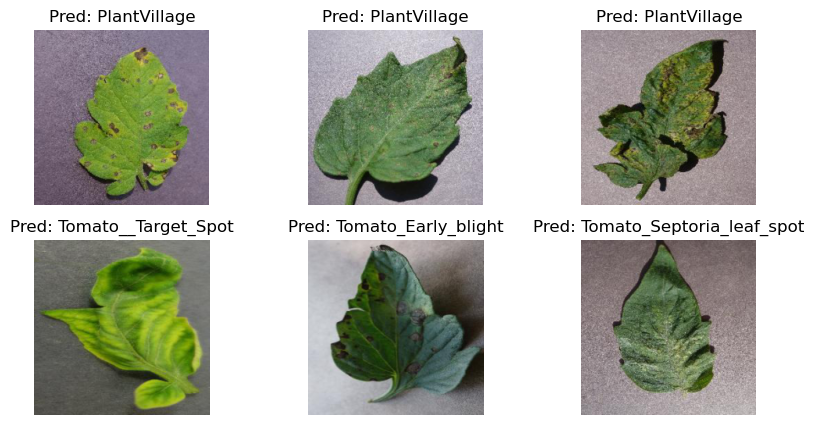

In [ ]:
images, labels = next(iter(test_loader))

outputs = model(images)

_, preds = torch.max(outputs, 1)

plt.figure(figsize=(10, 5))

for i in range(6):

    plt.subplot(2, 3, i + 1)

    img = images[i].permute(1, 2, 0)

    plt.imshow(img)

    plt.title(f"Pred: {classes[preds[i]]}")

    plt.axis("off")

plt.show()

I'LL update it here another time
